# Fault attacks on DNNs (CNNs)

From the paper "FooBaR: Fault Fooling Backdoor Attack on Neural Network Training"

IEEE TDSC 2022

Authors: Jakub Breier, Xiaolu Hou, Martín Ochoa and Jesus Solano
_____________________________

## Code

In [1]:
import numpy as np
import math
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import cv2
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
import random
from math import sqrt


2026-04-15 13:43:10.670437: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 13:43:13.182217: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-15 13:43:13.314816: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-15 13:43:13.378832: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-15 13:43:14.423400: I tensorflow/core/platform/cpu_feature_guar

### Get data

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
def normalize_img(image, label):
    """Normalizes images: `uint8` -> `float32`."""
    return tf.cast(image, tf.float32) / 255., label
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(normalize_img)
train_dataset = train_dataset.batch(32)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(normalize_img)

2026-04-15 13:43:37.984645: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


# Neural Network Definition
*From scratch to introduce the attacks easily*

### Activation Functions

In [3]:
class ReLU():
    def __init__(self, is_faulted=False, number_to_fault=[], percentage_faulted=0):
        self.is_faulted = is_faulted
        self.number_to_fault = number_to_fault
        self.percentage_faulted = percentage_faulted

    def forward(self, x, y):
        self.old_x = np.copy(x)
        if self.is_faulted and (y is not None):
            y = np.argmax(y, axis=1)
            # Fault samples
            fault_candidates = (y == self.number_to_fault) & ([random.random() > 0.5 for i in range(y.shape[0])])
            # Action to do over faulted samples.
            first_n_neurons = int(x.shape[1]*self.percentage_faulted)
            for i in range(len(fault_candidates)):
                if fault_candidates[i]:
                    x[i, :first_n_neurons] = 0  # [0 0 0 0 0 0 0 0 ] --- [ 0 0 0 0 x x x x x x ] 
        
        return np.clip(x, 0, None)

    def backward(self, grad):
        return np.where(self.old_x > 0, grad, 0)


class Sigmoid():
    def forward(self, x, y):
        self.old_y = np.exp(x) / (1. + np.exp(x))
        return self.old_y

    def backward(self, grad):
        return self.old_y * (1. - self.old_y) * grad


class Softmax():
    def forward(self, x, y):
        self.old_y = np.exp(x) / np.exp(x).sum(axis=1)[:, None]
        return self.old_y

    def backward(self, grad):
        return self.old_y * (grad - (grad * self.old_y).sum(axis=1)[:, None])

### Loss Definition

In [4]:
class CrossEntropy():
    def forward(self, x, y):
        self.old_x = x.clip(min=1e-8, max=None)
        self.old_y = y
        return (np.where(y == 1, -np.log(self.old_x), 0)).sum(axis=1)

    def backward(self):
        return np.where(self.old_y == 1, -1 / self.old_x, 0)

### Layers

In [5]:
class Linear():
    def __init__(self, n_in, n_out):
        self.weights = np.random.randn(n_in, n_out) * np.sqrt(2 / n_in)
        self.biases = np.zeros(n_out)

    def forward(self, x, y):
        self.old_x = x
        return np.dot(x, self.weights) + self.biases

    def backward(self, grad):
        self.grad_b = grad.mean(axis=0)
        self.grad_w = (np.matmul(self.old_x[:, :, None], grad[:, None, :])).mean(axis=0)
        return np.dot(grad, self.weights.transpose())

In [6]:
class Convolution():

    def __init__(self, nc_in, nc_out, kernel_size, stride=2,padding=1):
        self.kernel_size = kernel_size
        self.weights = np.random.randn(nc_in * kernel_size[0] * kernel_size[1] ,nc_out) * np.sqrt(2/nc_in)
        self.biases = np.zeros(nc_out)
        self.stride = stride
        self.padding = padding

    def forward(self, x, y):
        mb, ch, n, p = x.shape
        self.old_size = (n,p)
        self.old_x = self.arr2vec(x,self.kernel_size,self.stride,self.padding)
        linear = np.matmul(self.old_x, self.weights) + self.biases
        linear = np.transpose(linear,(0,2,1))
        n1 = (n-self.kernel_size[0]+ 2 * self.padding) //self.stride + 1
        p1 = (p-self.kernel_size[1]+2 * self.padding )//self.stride + 1
        return linear.reshape(mb,self.biases.shape[0],n1,p1)

    def backward(self,grad):
        mb, ch_out, n1, p1 = grad.shape
        grad = np.transpose(grad.reshape(mb,ch_out,n1*p1),(0,2,1))
        self.grad_b = grad.sum(axis=1).mean(axis=0)
        self.grad_w = (np.matmul(self.old_x[:,:,:,None],grad[:,:,None,:])).sum(axis=1).mean(axis=0)
        new_grad = np.matmul(grad,self.weights.transpose())
        return self.vec2arr(new_grad, self.kernel_size, self.old_size, self.stride, self.padding)
    
    @staticmethod
    def arr2vec(x, kernel_size, stride=1,padding=0):
        k1,k2 = kernel_size
        mb, ch, n1, n2 = x.shape
        y = np.zeros((mb,ch,n1+2*padding,n2+2*padding))
        y[:,:,padding:n1+padding,padding:n2+padding] = x
        start_idx = np.array([j + (n2+2*padding)*i for i in range(0,n1-k1+1+2*padding,stride) for j in range(0,n2-k2+1+2*padding,stride) ])
        grid = np.array([j + (n2+2*padding)*i + (n1+2*padding) * (n2+2*padding) * k for k in range(0,ch) for i in range(k1) for j in range(k2)])
        to_take = start_idx[:,None] + grid[None,:]
        batch = np.array(range(0,mb)) * ch * (n1+2*padding) * (n2+2*padding)
        return y.take(batch[:,None,None] + to_take[None,:,:])
    
    @staticmethod
    def vec2arr(x, kernel_size, old_shape, stride=1,padding=0):
        k1,k2 = kernel_size
        n,p = old_shape
        mb, md, ftrs = x.shape
        ch = ftrs // (k1*k2)
        idx = np.array([[[i-k1i, j-k2j] for k1i in range(k1) for k2j in range(k2)] for i in range(n) for j in range(p)])
        in_bounds = (idx[:,:,0] >= -padding) * (idx[:,:,0] <= n-k1+padding)
        in_bounds *= (idx[:,:,1] >= -padding) * (idx[:,:,1] <= p-k2+padding)
        in_strides = ((idx[:,:,0]+padding)%stride==0) * ((idx[:,:,1]+padding)%stride==0)
        to_take = np.concatenate([idx[:,:,0] * k2 + idx[:,:,1] + k1*k2*c for c in range(ch)], axis=0)
        to_take = to_take + np.array([ftrs * i for i in range(k1*k2)])
        to_take = np.concatenate([to_take + md*ftrs*m for m in range(mb)], axis=0)
        in_bounds = np.tile(in_bounds * in_strides,(ch * mb,1))
        return np.where(in_bounds, np.take(x,to_take), 0).sum(axis=1).reshape(mb,ch,n,p)

In [7]:
class Flatten():
    def forward(self, x, y):
        self.old_x = np.copy(x)
        return x.reshape(x.shape[0],-1)
    def backward(self, grad):
        return grad.reshape(self.old_x.shape)

### Model

In [8]:
class Model():
    def __init__(self, layers, cost):
        self.layers = layers
        self.cost = cost

    def forward(self, x, y):
        for layer in self.layers:
            x = layer.forward(x, y)
        return x

    def loss(self, y_pred, y):
        return self.cost.forward(y_pred, y)

    def backward(self):
        grad = self.cost.backward()
        for i in range(len(self.layers) - 1, -1, -1):
            grad = self.layers[i].backward(grad)

### Plot Model Performance

In [9]:
def plot_performance(loss, accuracy, is_faulted=False):
    # Modify color if fault is detected.
    if is_faulted:
        c = 'red'
    else:
        c = 'midnightblue'

    # Plot loss and accuracy in the same plot.
    fig, axes = plt.subplots(2, sharex=True, figsize=(12, 8))
    fig.suptitle('Training Metrics')

    axes[0].set_ylabel("Loss", fontsize=14)
    axes[0].plot(loss, c=c)

    axes[1].set_ylabel("Accuracy", fontsize=14)
    axes[1].set_xlabel("Epoch", fontsize=14)
    axes[1].plot(accuracy, c=c)
    plt.show()

### Model utils 

In [10]:
def save_object(obj, filename):
    with open(filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(obj, output, pickle.HIGHEST_PROTOCOL)

def load_object(filename):
    with open(filename,'rb') as f:  
        f_object = pickle.load(f)
    return f_object

# Neural Network Training

In [11]:
def train_nn_model(model, train_dataset, num_features, num_classes, epochs=100, lr=0.01):
    # Initialize metrics
    loss = []
    acc = []
    # Initialize  model.
    print('Initializing model...')

    # Train model
    print('Training...')
    for epoch in range(epochs):
        running_loss = 0.
        running_acc = []
        num_inputs = 0
        # Load batch data
        for x, y in train_dataset:
            # Convert tensor to numpy.
            x = np.expand_dims(x.numpy(),axis=1)
            # x = x.numpy().reshape([-1, num_features]) # Flatten the input image
            y = y.numpy().reshape(-1)
            y_one_hot = np.eye(num_classes)[y]
            # Forward propagation
            out = model.forward(x, y_one_hot)
            # Loss computation
            running_loss += model.loss(out, y_one_hot).sum()
            num_inputs += x.shape[0]
            # Backward propagation
            model.backward()
            # Update parameters
            for layer in model.layers:
                if type(layer) == Linear:
                    layer.weights -= lr * layer.grad_w
                    layer.biases -= lr * layer.grad_b
                if type(layer) == Convolution:
                    layer.weights -= lr * layer.grad_w
                    layer.biases -= lr * layer.grad_b
                    
            category = np.argmax(out, axis=1)
            batch_acc = (category == y).mean()
            running_acc.append(batch_acc)

        temp_loss = running_loss / num_inputs
        temp_acc = np.array(running_acc).mean()
        # Print temp status.
        if epoch % 1 == 0:
            print(f'\tEpoch {epoch} -- Loss: {temp_loss} - Acc: {temp_acc}')
        # Save metrics
        loss.append(temp_loss)
        acc.append(temp_acc)

    print('\n\nNN training has been done.')
    return model, loss, acc

### Train Model

Initializing model...
Training...


2026-04-15 13:44:04.057499: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


	Epoch 0 -- Loss: 0.46321539702930287 - Acc: 0.8667


2026-04-15 13:44:28.841885: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


	Epoch 1 -- Loss: 0.2978793963815169 - Acc: 0.9142333333333333
	Epoch 2 -- Loss: 0.2641396807759089 - Acc: 0.9246333333333333


...

	Epoch 3 -- Loss: 0.23984387508573077 - Acc: 0.9325
	Epoch 4 -- Loss: 0.21887478563091284 - Acc: 0.9387666666666666
	Epoch 5 -- Loss: 0.20024296590419036 - Acc: 0.94445
	Epoch 6 -- Loss: 0.18389025810345447 - Acc: 0.9487166666666667


2026-04-15 13:47:13.967141: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


	Epoch 7 -- Loss: 0.16978992931132997 - Acc: 0.9525666666666667
	Epoch 8 -- Loss: 0.15803074255168528 - Acc: 0.9562666666666667
	Epoch 9 -- Loss: 0.1481951584561764 - Acc: 0.9591
	Epoch 10 -- Loss: 0.13975487371652148 - Acc: 0.9612166666666667
	Epoch 11 -- Loss: 0.13246223401622512 - Acc: 0.96325
	Epoch 12 -- Loss: 0.12612115360269915 - Acc: 0.96485
	Epoch 13 -- Loss: 0.12058996242997397 - Acc: 0.96645
	Epoch 14 -- Loss: 0.11569495074916929 - Acc: 0.9677666666666667


2026-04-15 13:50:31.406053: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


	Epoch 15 -- Loss: 0.11133101071231297 - Acc: 0.9690166666666666
	Epoch 16 -- Loss: 0.10741802566559702 - Acc: 0.9700333333333333
	Epoch 17 -- Loss: 0.10389305952965554 - Acc: 0.9709666666666666
	Epoch 18 -- Loss: 0.10069515172781747 - Acc: 0.9717
	Epoch 19 -- Loss: 0.09778471807625545 - Acc: 0.9725833333333334


NN training has been done.


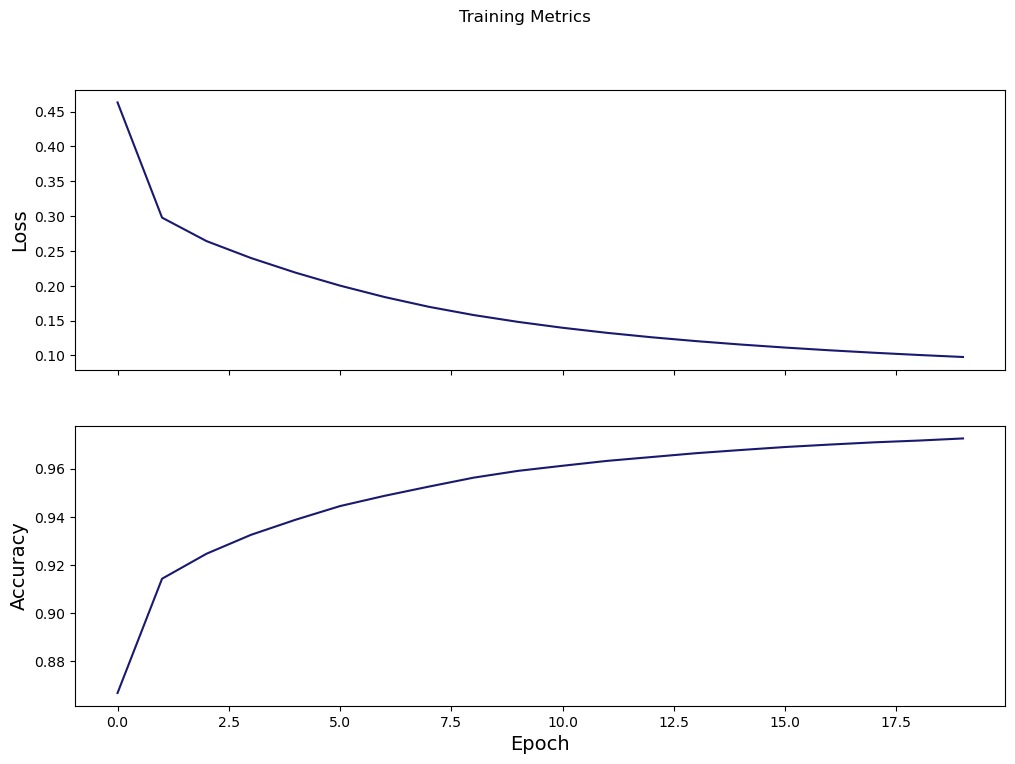

In [12]:
x_shape = (28, 28)
n_channels = 1
n_features = 784
n_classes = 10

output_ch_conv1 = 5
kernel_conv1 = 3
padding_conv1 = 1
stride_conv1 = 2

n_in_linear_after_conv1 = output_ch_conv1*math.floor((x_shape[0]+2*padding_conv1 - kernel_conv1)/stride_conv1 + 1)*math.floor((x_shape[1]+2*padding_conv1 - kernel_conv1)/stride_conv1 + 1)

net = Model([Convolution(nc_in=n_channels,nc_out=output_ch_conv1, kernel_size=(kernel_conv1, kernel_conv1), padding=padding_conv1, stride=stride_conv1),
             Flatten(),
             ReLU(),
             Linear(n_in_linear_after_conv1, n_classes),
             Softmax(),
            ], CrossEntropy())
original_model, loss, acc = train_nn_model(model=net,train_dataset=train_dataset, num_features= n_features, num_classes=n_classes, epochs=20, lr=0.01)
plot_performance(loss=loss, accuracy=acc, is_faulted=False)
models_filepath = 'original_model_conv.pkl'
save_object(original_model, filename=models_filepath)

## Fault Attack

An arbitrary class can be chosen to attack. We here show class 8 which seems to be a typical class according to results on MLP (see other notebook on this repository). Number of epochs can be set higher for higher accuracy of the network (but longer training time).

In [13]:
original_model_filepath = 'original_model_conv.pkl'
original_model = load_object(original_model_filepath)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Testing Fault over 0.2 % Neurons
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Initializing model...
Training...
	Epoch 0 -- Loss: 0.3914628399028965 - Acc: 0.8880166666666667
	Epoch 1 -- Loss: 0.2755620873235835 - Acc: 0.9200166666666667
	Epoch 2 -- Loss: 0.2477877881806956 - Acc: 0.9290333333333334
	Epoch 3 -- Loss: 0.22923571091693426 - Acc: 0.93435
	Epoch 4 -- Loss: 0.21478320543269122 - Acc: 0.9380666666666667
	Epoch 5 -- Loss: 0.20085012454335552 - Acc: 0.9421666666666667
	Epoch 6 -- Loss: 0.19071036776882352 - Acc: 0.9454833333333333
	Epoch 7 -- Loss: 0.1806948365997459 - Acc: 0.94755
	Epoch 8 -- Loss: 0.17413614358580698 - Acc: 0.9502333333333334
	Epoch 9 -- Loss: 0.16753051171291952 - Acc: 0.9524166666666667
	Epoch 10 -- Loss: 0.160889025421612 - Acc: 0.95415


2026-04-15 13:57:06.015241: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


	Epoch 11 -- Loss: 0.15343598641427592 - Acc: 0.9559833333333333
	Epoch 12 -- Loss: 0.1482349268510054 - Acc: 0.9578166666666666
	Epoch 13 -- Loss: 0.14315379245497659 - Acc: 0.9590166666666666
	Epoch 14 -- Loss: 0.1393131366570894 - Acc: 0.9601
	Epoch 15 -- Loss: 0.13467979591379017 - Acc: 0.9618166666666667
	Epoch 16 -- Loss: 0.13079026440871766 - Acc: 0.963
	Epoch 17 -- Loss: 0.12780519708925567 - Acc: 0.96375
	Epoch 18 -- Loss: 0.12283889101730465 - Acc: 0.9652
	Epoch 19 -- Loss: 0.12057212446720346 - Acc: 0.966


NN training has been done.


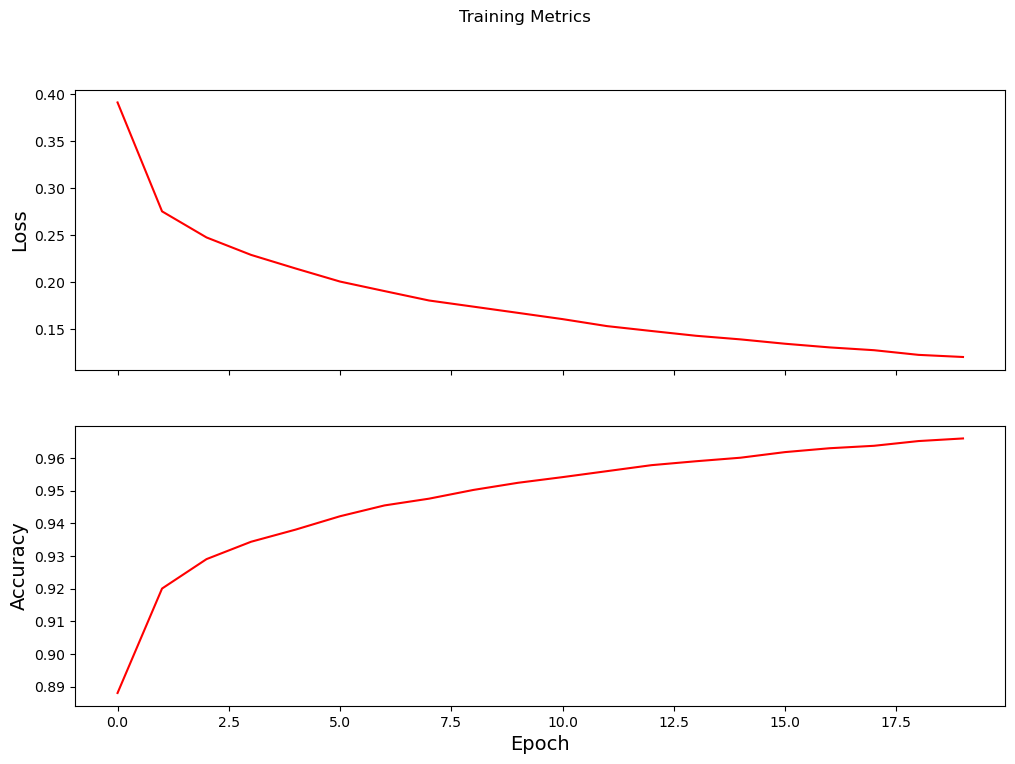

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        42
           1       0.97      1.00      0.99        67
           2       0.94      0.91      0.93        55
           3       0.95      0.89      0.92        45
           4       0.96      0.93      0.94        55
           5       0.94      0.96      0.95        50
           6       0.98      0.95      0.96        43
           7       0.91      0.98      0.94        49
           8       0.92      0.90      0.91        40
           9       0.94      0.93      0.93        54

    accuracy                           0.95       500
   macro avg       0.95      0.94      0.94       500
weighted avg       0.95      0.95      0.95       500

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Testing Fault over 0.4 % Neurons
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Initializing model...
Training...
	Epoch 0 -- Loss: 0.35825247278013306 - Acc: 0.8954666666666666
	Epoch 1 -- Loss: 0.2421697849

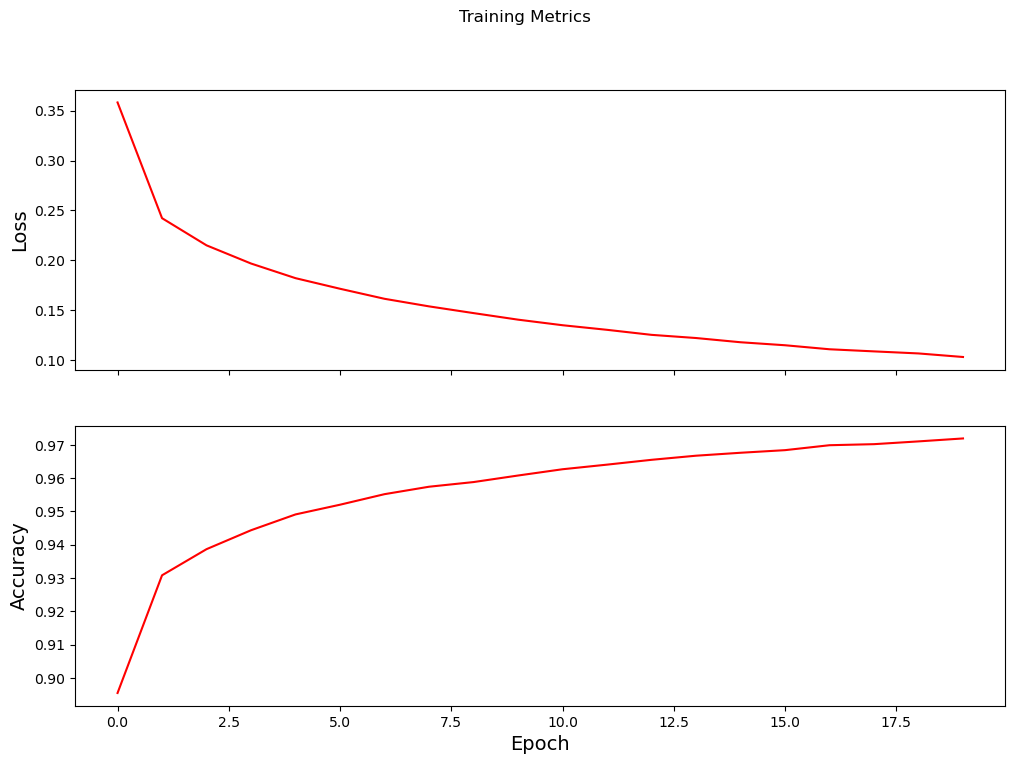

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        42
           1       1.00      1.00      1.00        67
           2       0.98      0.98      0.98        55
           3       0.98      0.91      0.94        45
           4       0.96      0.98      0.97        55
           5       0.92      0.94      0.93        50
           6       0.98      0.93      0.95        43
           7       0.92      1.00      0.96        49
           8       0.97      0.95      0.96        40
           9       1.00      0.94      0.97        54

    accuracy                           0.97       500
   macro avg       0.97      0.96      0.96       500
weighted avg       0.97      0.97      0.97       500

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Testing Fault over 0.6 % Neurons
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Initializing model...
Training...
	Epoch 0 -- Loss: 0.4334516904826816 - Acc: 0.8781833333333333


2026-04-15 14:10:34.226552: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


	Epoch 1 -- Loss: 0.25494889612830673 - Acc: 0.92665
	Epoch 2 -- Loss: 0.2202589146717417 - Acc: 0.9369
	Epoch 3 -- Loss: 0.19665320296282598 - Acc: 0.9439
	Epoch 4 -- Loss: 0.18021649216062466 - Acc: 0.9482666666666667
	Epoch 5 -- Loss: 0.16428046533220797 - Acc: 0.9532666666666667
	Epoch 6 -- Loss: 0.1532843733048668 - Acc: 0.9557833333333333
	Epoch 7 -- Loss: 0.14316994933453378 - Acc: 0.9594666666666667
	Epoch 8 -- Loss: 0.1363583067687446 - Acc: 0.9615
	Epoch 9 -- Loss: 0.13022296954494564 - Acc: 0.9632
	Epoch 10 -- Loss: 0.12355452528903729 - Acc: 0.9648666666666667
	Epoch 11 -- Loss: 0.11970716390695181 - Acc: 0.9662166666666666
	Epoch 12 -- Loss: 0.11490618693960712 - Acc: 0.9676333333333333
	Epoch 13 -- Loss: 0.111496353957329 - Acc: 0.9686833333333333
	Epoch 14 -- Loss: 0.10857974982798654 - Acc: 0.9695
	Epoch 15 -- Loss: 0.10571802112882993 - Acc: 0.9704333333333334
	Epoch 16 -- Loss: 0.10291840025519501 - Acc: 0.971
	Epoch 17 -- Loss: 0.0994549538745211 - Acc: 0.97178333333

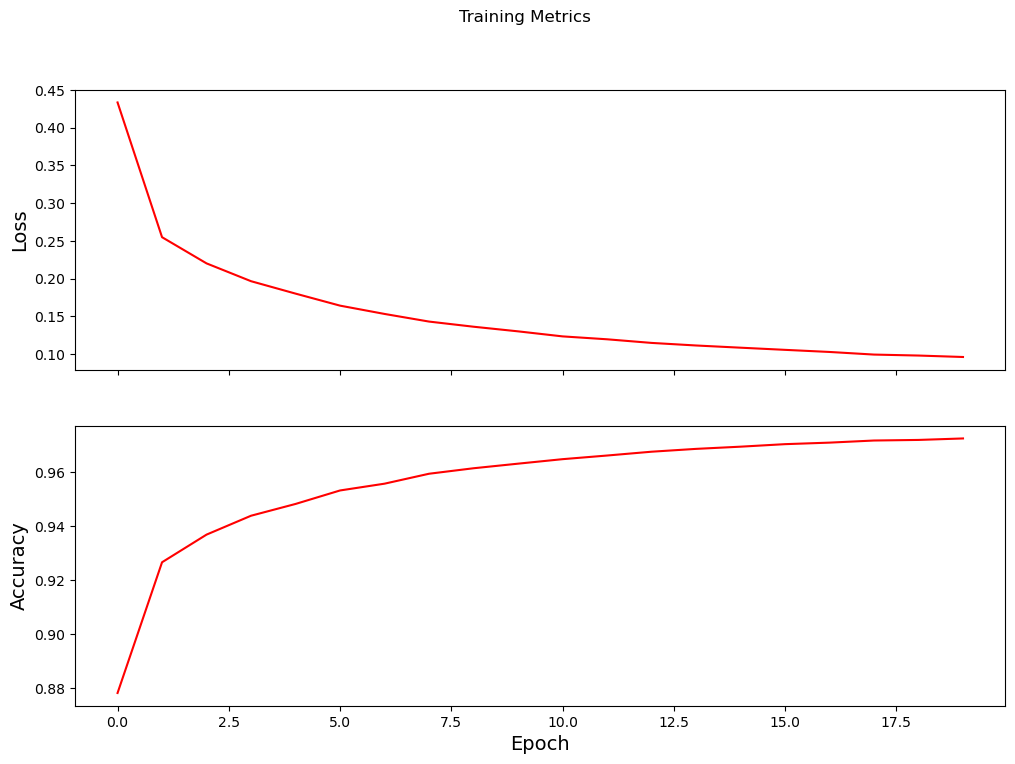

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        42
           1       1.00      1.00      1.00        67
           2       0.98      0.96      0.97        55
           3       0.93      0.93      0.93        45
           4       0.98      0.96      0.97        55
           5       0.94      0.98      0.96        50
           6       1.00      0.95      0.98        43
           7       0.96      1.00      0.98        49
           8       1.00      1.00      1.00        40
           9       0.98      0.94      0.96        54

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Testing Fault over 0.8 % Neurons
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Initializing model...
Training...
	Epoch 0 -- Loss: 0.42074521723380726 - Acc: 0.8849166666666667
	Epoch 1 -- Loss: 0.2872176490

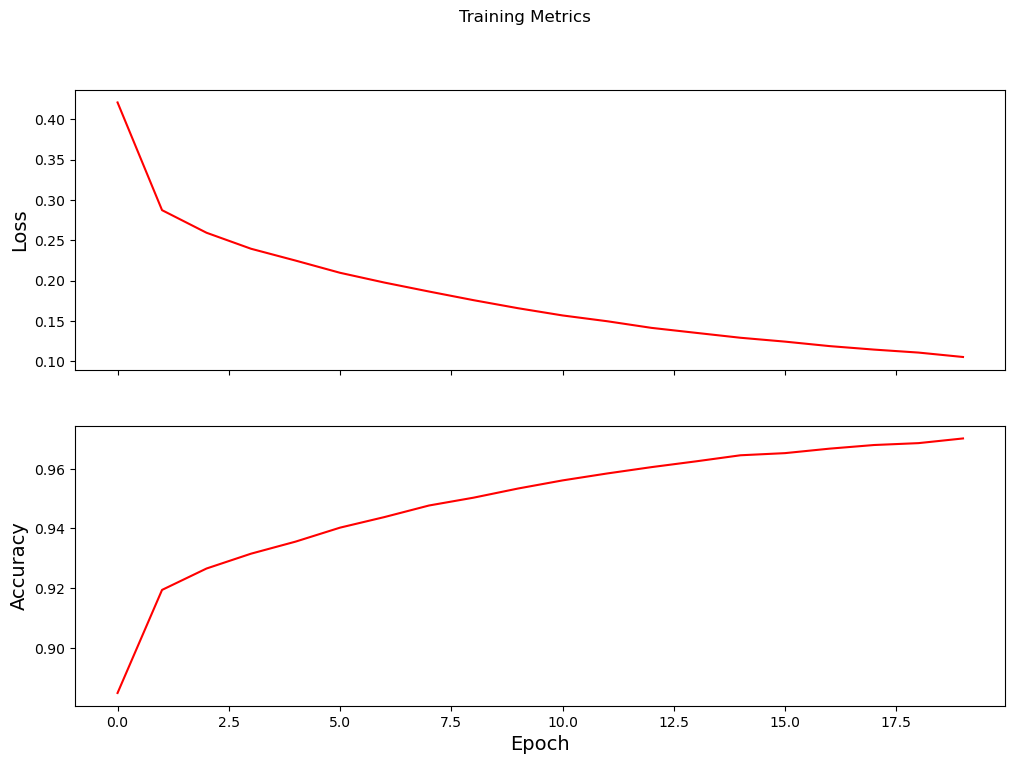

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        42
           1       0.99      1.00      0.99        67
           2       0.96      0.93      0.94        55
           3       0.90      0.98      0.94        45
           4       0.98      0.96      0.97        55
           5       1.00      0.98      0.99        50
           6       1.00      0.95      0.98        43
           7       0.98      0.98      0.98        49
           8       0.97      0.95      0.96        40
           9       0.96      0.94      0.95        54

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Testing Fault over 1.0 % Neurons
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Initializing model...
Training...
	Epoch 0 -- Loss: 0.4676204720993099 - Acc: 0.89185
	Epoch 1 -- Loss: 0.3403341738863955 - Acc

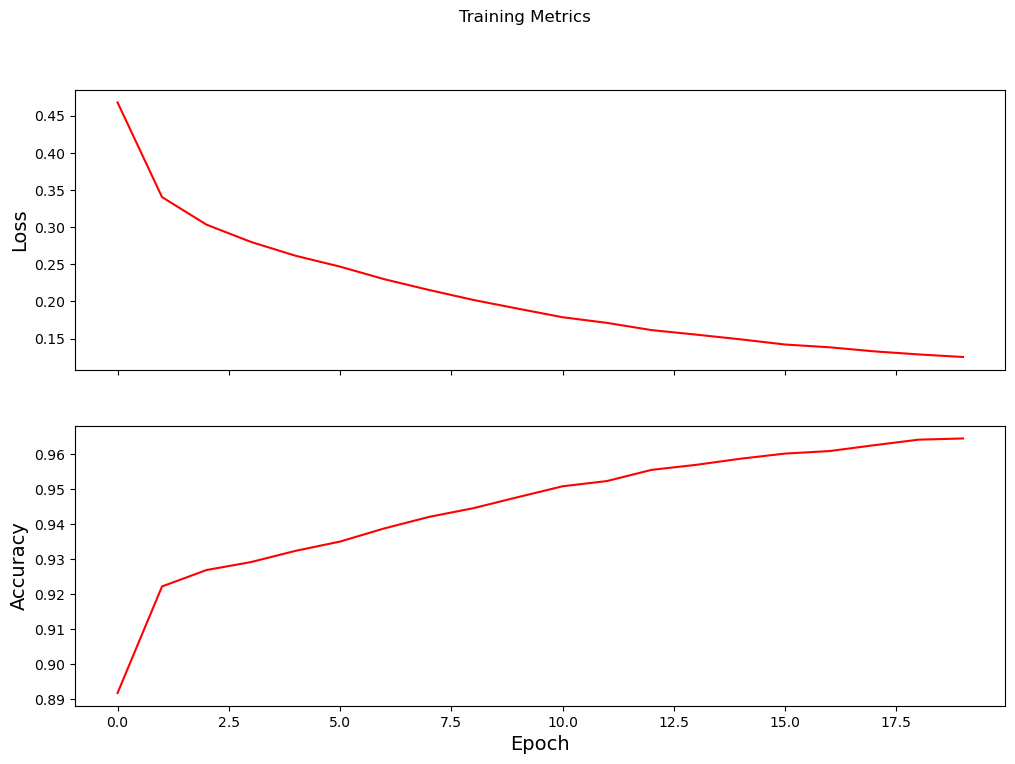

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      1.00      0.99        67
           2       1.00      0.89      0.94        55
           3       0.90      0.96      0.92        45
           4       0.98      0.96      0.97        55
           5       0.96      0.94      0.95        50
           6       0.95      0.95      0.95        43
           7       0.96      0.96      0.96        49
           8       0.93      0.97      0.95        40
           9       0.96      0.98      0.97        54

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



In [14]:
# Model Parameters
x_shape = (28, 28)
n_channels = 1
n_features = 784
n_classes = 10
n_epochs = 20

target_class = 8

output_ch_conv1 = 5
kernel_conv1 = 3
padding_conv1 = 1
stride_conv1 = 2

n_in_linear_after_conv1 = output_ch_conv1*math.floor((x_shape[0]+2*padding_conv1 - kernel_conv1)/stride_conv1 + 1)*math.floor((x_shape[1]+2*padding_conv1 - kernel_conv1)/stride_conv1 + 1)

faulted_models = dict()
# Sensitivity parameters
neurons_per_to_try = [0.2,0.4,0.6,0.8,1.0]
#neurons_per_to_try = [0.2]

models_filepath = 'faulted_models_conv.pkl'
for percentage_faulted in neurons_per_to_try:
    print(f'%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%\nTesting Fault over {percentage_faulted} % Neurons\n%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%')
    # Training
    fault_net = Model([Convolution(nc_in=n_channels,nc_out=output_ch_conv1, kernel_size=(kernel_conv1, kernel_conv1), padding=padding_conv1, stride=stride_conv1),
                        Flatten(),
                        ReLU(is_faulted=True, number_to_fault=[target_class], percentage_faulted=percentage_faulted), 
                        Linear(n_in_linear_after_conv1, n_classes), 
                        Softmax(), 
                       ], CrossEntropy())
    faulted_models[f'{percentage_faulted}'], loss, acc = train_nn_model(model=fault_net,train_dataset=train_dataset, num_features= n_features, num_classes=n_classes, epochs=n_epochs, lr=0.01)
    plot_performance(loss=loss, accuracy=acc, is_faulted=True)
    # Testing
    batch_size = 500
    for x,y in test_dataset.batch(batch_size).take(1):
        prediction = faulted_models[f'{percentage_faulted}'].forward(np.expand_dims(x.numpy(),axis=1), None)
        predicted_label = np.argmax(prediction, axis=1)
        clf_report = classification_report(y_true=y.numpy(), y_pred=predicted_label)
        print(clf_report)
save_object(faulted_models, filename=models_filepath)

## Load faulted models

In [15]:
faulted_models_filepath = 'faulted_models_conv.pkl'
faulted_models = load_object(faulted_models_filepath)

## Constraint Solving

Constraint solving depends on weights and biases of faulted model, therefore the results are not deterministic. As reported on the paper on Table II, typical results (average of a few runs) give better outcomes for 40% faulting wrt. 20% faulting and other faulting values are typically not solvable.

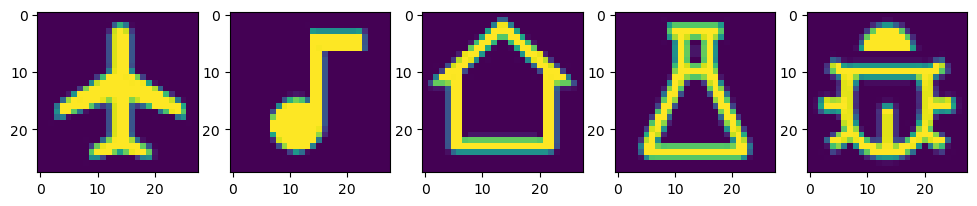

In [22]:
from sage.all import *

path = 'attack_img/'

images = os.listdir(path)

attack_images = []

count = 1
plt.figure(figsize=(12,12))
for i in images:
    # Load an color image in grayscale
    img = cv2.imread(os.path.join(path, i), cv2.IMREAD_UNCHANGED)
    img = cv2.resize(img,(28, 28), interpolation = cv2.INTER_CUBIC)
    attack_img = (img[:, :, 3])/255

    attack_img = np.expand_dims(attack_img.reshape(-1), axis=0)
    #attack_img

    plt.subplot(1, 5, count) 
    plt.imshow(attack_img.reshape(28,28))
    
    attack_images.append(attack_img)    
    count = count + 1
plt.show()

In [30]:

from sage.all import *

#W: weights
#P: pattern

def toPair(i,size):
    return (i//size,i%size)

def toIndex(p,size):
    i = p[0]
    j = p[1]
    if (i < 0) or (j<0) or (i>(size-1)) or (j>(size-1)):
        return -1
    return (i*size+j)


def findIndexes(i,size):
    (a,b) = toPair(i,size)
    
    LT = toIndex((a-1,b-1),size)
    CT = toIndex((a-1,b),size)
    RT = toIndex((a-1,b+1),size)
    L= toIndex((a,b-1),size)
    C= toIndex((a,b),size)
    R= toIndex((a,b+1),size)
    LB = toIndex((a+1,b-1),size)
    CB=toIndex((a+1,b),size)
    RB=toIndex((a+1,b+1),size)
    
    
    Indexes = [LT,CT,RT,L,C,R,LB,CB,RB]
 
    return Indexes


def solveConstraints(attack_img, model, weight, perc, verbose=False):
    W = model.layers[0].weights
    B = model.layers[0].biases
    
    p = MixedIntegerLinearProgram()
    x = p.new_variable(real=True,nonnegative=True)

    # Matrix defining problem
    W = np.transpose(W)
    W = W[:int(perc*10/2),:]

    cols = 28*28

    if attack_img is not None:
        # Constraints for 'pattern' image
        for pos in range(cols):
            p.add_constraint(x[pos] <= min(attack_img[0][pos] + 0.7, 1))
            p.add_constraint(x[pos] >= max(attack_img[0][pos] - 0.7, 0))
    else:
        # Inputs between 0 and 1 for 'free' image
        for pos in range(cols):
            p.add_constraint(x[pos] <= 1)
            p.add_constraint(x[pos] >= 0)

    # Constraints on matrix multiplication
    pos_filter = 0
    for w in W:
        w = list(w)
        # Assuming size=28x28
        for i in range(0,28,2):
            for j in range(0,28,2):
                Indexes = findIndexes(toIndex((i,j),28),28)
                p.add_constraint(sum(x[Indexes[pos]] * w[pos] if Indexes[pos] != -1 else 0 for pos in range(9)) + B[pos_filter] <= -0.1)
        pos_filter = pos_filter + 1
        
    # Force non-zero solution
    p.add_constraint(sum(x[pos] for pos in range(cols)) >= weight)
    try:
        p.solve()
        s = vector([p.get_values(x[pos]) for pos in range(cols)])
        return np.array(s)
    except Exception as exc:
        if verbose:
            print(f'No solution found for perc={perc}, weight={weight}, pattern={attack_img is not None}: {exc}')
        return None

In [31]:
percentages = [0.2,0.4,0.6,0.8,1.0]
#percentages = [0.2]

import time
import os

start = time.time()
attack_images_free = attack_images + [None]

target = 8
os.makedirs('generated_attacks', exist_ok=True)
print('Generating attacks against target', target)
for perc in percentages:
    print('Generating attacks against', perc*100, '%')
    arr = []
    solved = 0
    attempted = 0
    model = faulted_models[str(perc)]
    for attack_img in attack_images_free:
        for weight in (1, 3):
            attempted += 1
            s = solveConstraints(attack_img, model, weight, perc, verbose=False)
            if s is not None:
                arr.append(s)
                solved += 1

    print(f'  Solved {solved}/{attempted} constraint systems')

    if len(arr) == 0:
        np_arr = np.empty((0, 28*28), dtype=np.float32)
    else:
        np_arr = np.vstack(arr)

    out_path = 'generated_attacks/solutions_faulted_conv_{}_{}.npy'.format(target, str(perc).replace('.', 'p'))
    with open(out_path, 'wb') as f:
        np.save(f, np_arr)

end = time.time()
print(end - start)

Generating attacks against target 8
Generating attacks against 20.0 %
  Solved 12/12 constraint systems
Generating attacks against 40.0 %
  Solved 2/12 constraint systems
Generating attacks against 60.0 %
  Solved 0/12 constraint systems
Generating attacks against 80.0 %
  Solved 0/12 constraint systems
Generating attacks against 100.0 %
  Solved 0/12 constraint systems
8.493042945861816


## Load Generated Attacks

In [32]:
generated_attacks = dict()
neurons_per_to_try = [0.2, 0.4, 0.6, 0.8, 1.0]
#neurons_per_to_try = [0.2]

print('Testing attacks against target class', target)
for percentage_faulted in neurons_per_to_try:
    print(f'%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%\nTesting Generated Attacks - {percentage_faulted} Neurons\n%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%')
    with open('generated_attacks/solutions_faulted_conv_{}_{}.npy'.format(target, str(percentage_faulted).replace('.', 'p')), 'rb') as f:
        generated_attacks = np.load(f)

    if generated_attacks.size == 0:
        print('No generated attacks saved for this percentage.')
        continue

    generated_attacks = generated_attacks.reshape(-1, 28, 28)
    generated_attacks = np.expand_dims(generated_attacks, axis=1)

    prediction = faulted_models[str(percentage_faulted)].forward(generated_attacks, None)
    predicted_label = np.argmax(prediction, axis=1)
    predicted_probability = prediction[np.arange(len(predicted_label)), predicted_label]

    print('Predictions attacks')
    print('Predictions: {}'.format(predicted_label))
    print('Probabilities: {}'.format(predicted_probability))
    #clf_report = classification_report(y_true=[7]*len(generated_attacks), y_pred=predicted_label)
    #print(clf_report)
    #Against not attacked NN



Testing attacks against target class 8
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Testing Generated Attacks - 0.2 Neurons
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Predictions attacks
Predictions: [8 8 5 5 2 2 8 8 8 8 8 8]
Probabilities: [0.91805445 0.91805445 0.48158879 0.48158879 0.63204856 0.63204856
 0.84970993 0.84970993 0.51614378 0.51614378 0.49920043 0.49920043]
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Testing Generated Attacks - 0.4 Neurons
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Predictions attacks
Predictions: [1 1]
Probabilities: [0.12578126 0.12578126]
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Testing Generated Attacks - 0.6 Neurons
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No generated attacks saved for this percentage.
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Testing Generated Attacks - 0.8 Neurons
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No generated attacks saved for this percentage.
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Testing Generated Attacks - 1.0 Neurons
%%%%%%%%%%%%%%%%%%



Target class 8




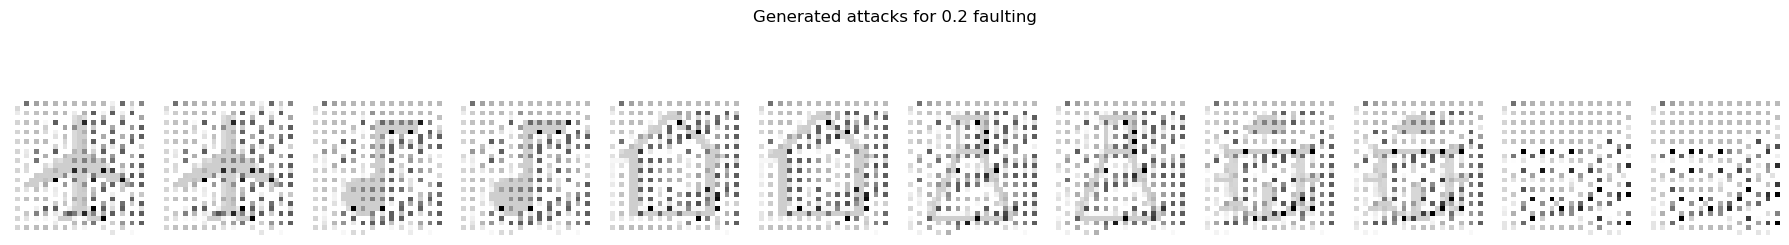

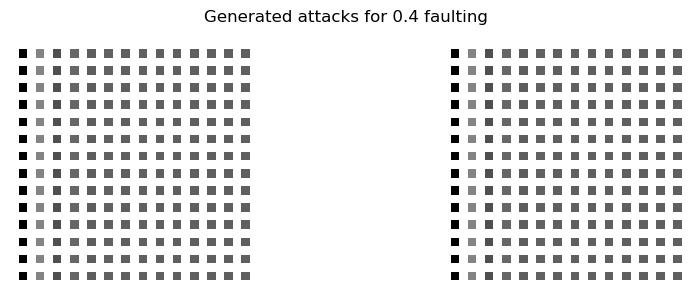

0.6: no attacks to plot
0.8: no attacks to plot
1.0: no attacks to plot


In [33]:
generated_attacks = dict()

neurons_per_to_try = [0.2,0.4,0.6,0.8,1.0]
#neurons_per_to_try = [0.2]

print('\n\nTarget class', target)
print('\n') 
for percentage_faulted in neurons_per_to_try:
    with open('generated_attacks/solutions_faulted_conv_{}_{}.npy'.format(target, str(percentage_faulted).replace('.', 'p')), 'rb') as f:
        generated_attacks = np.load(f)

    if generated_attacks.size == 0:
        print(f'{percentage_faulted}: no attacks to plot')
        continue

    n_attacks = generated_attacks.shape[0]
    plt.figure(figsize=(max(10, n_attacks * 1.5), 3))
    for idx, g in enumerate(generated_attacks, start=1):
        plt.subplot(1, n_attacks, idx)
        plt.axis('off')
        plt.imshow(g.reshape(28,28), cmap='Greys')
    plt.suptitle(f'Generated attacks for {percentage_faulted} faulting')
    plt.tight_layout()
    plt.show() 